In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
mod = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.m5c.tsv"
unmod = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.unmod.c.tsv"
kmer_encode_dic={'A': 0, "C": 1, "G": 2, "T": 3}
def load_predict_data(file, data_length=50):
    mean_list = []
    std_list = []
    intense_list = []
    dwell_list = []
    
    count = 0
    with open(file) as f:
        for line in f:
            line = line.rstrip()
            items = line.split("\t")
            kmer = items[3]
            mean = np.array([float(item) for item in items[4].split("|")])
            std = np.array([float(item) for item in items[5].split("|")])
            intense = np.array([float(item) for item in items[6].split("|")])
            dwell = np.array([float(item) for item in items[7].split("|")]) / 200
            mean_list.append(np.mean(mean))      # 取均值
            std_list.append(np.mean(std))
            intense_list.append(np.mean(intense))
            dwell_list.append(np.mean(dwell))
            count += 1
            print(count)
            if count >= data_length:
                break  
    return pd.DataFrame({
        "Mean": mean_list,
        "Std": std_list,
        "Median": intense_list,
        "Dwell": dwell_list
    })

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns

mod = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.m5c.tsv"
unmod = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.unmod.c.tsv"
def load_predict_data(file, data_length=50):
    X = []  
    count = 0
    with open(file) as f:
        for line in f:
            line = line.rstrip()
            items = line.split("\t")

            # 解析 5-mer 相关统计特征
            mean = np.array([float(item) for item in items[4].split("|")])  # 5 个 mean 值
            std = np.array([float(item) for item in items[5].split("|")])   # 5 个 std 值
            intensity = np.array([float(item) for item in items[6].split("|")])  # 5 个 intensity 值
            dwell = np.array([float(item) for item in items[7].split("|")])   # 5 个 dwell 值 (归一化)
            base_quality = np.array([float(item) for item in items[8].split("|")])  # 5 个 signal 值
            # 组合成 (5, 5) 结构
            sample_features = np.stack([mean[2], std[2], intensity[2], dwell[2], base_quality[2]], axis=0)
            X.append(sample_features)
            count += 1
            if count >= data_length: 
                break
    return np.array(X)  
mod_data = load_predict_data(mod)
unmod_data = load_predict_data(unmod)
print("Mod 数据形状:", mod_data.shape)  
print("Unmod 数据形状:", unmod_data.shape) 

Mod 数据形状: (50, 5)
Unmod 数据形状: (50, 5)


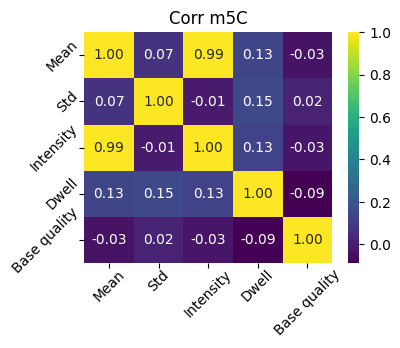

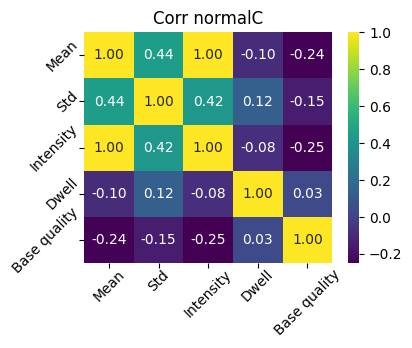

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

columns = ["Mean", "Std", "Intensity", "Dwell", "Base quality"]
mod_df = pd.DataFrame(mod_data, columns=columns)
unmod_df = pd.DataFrame(unmod_data, columns=columns)
mod_corr = mod_df.corr()
unmod_corr = unmod_df.corr()

color1 = (118/255, 113/255, 180/255) 
color2 = (232/255, 30/255, 41/255)   
custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', [color1, color2], N=256)

plt.figure(figsize=(4, 3))
ax_mod = sns.heatmap(mod_corr, annot=True, cmap='viridis', fmt=".2f",cbar={"alpha":0.8})
ax_mod.set_xticklabels(ax_mod.get_xticklabels(), rotation=45)
ax_mod.set_yticklabels(ax_mod.get_yticklabels(), rotation=45)
ax_mod.tick_params(axis='x', pad=-0.5) 
ax_mod.tick_params(axis='y', pad=-1) 
plt.title("Corr m5C", fontsize=12)
plt.savefig("f2mod_stats_correlation.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(4, 3))
ax_unmod = sns.heatmap(unmod_corr, annot=True, cmap="viridis", fmt=".2f",cbar={"alpha":0.8})
ax_unmod.set_xticklabels(ax_unmod.get_xticklabels(), rotation=45)
ax_unmod.set_yticklabels(ax_unmod.get_yticklabels(), rotation=45)
ax_unmod.tick_params(axis='x', pad=-0.5) 
ax_unmod.tick_params(axis='y', pad=-1)  
plt.title("Corr normalC",fontsize=12)
plt.savefig("f2unmod_stats_correlation.pdf", format="pdf", dpi=300, bbox_inches="tight") 
plt.show()